In [1]:
!pip install tensorflow scikit-learn matplotlib seaborn opencv-python kagglehub

In [2]:
!pip install kagglehub

In [3]:
import kagglehub

path = kagglehub.dataset_download("emmarex/plantdisease")
print("Dataset path:", path)

Using Colab cache for faster access to the 'plantdisease' dataset.
Dataset path: /kaggle/input/plantdisease


In [4]:
import os

for item in os.listdir(path):
    print(item)

PlantVillage
plantvillage


In [5]:
import os

pv = os.path.join(path, "PlantVillage")

for item in os.listdir(pv)[:30]:
    print(item)

Pepper__bell___Bacterial_spot
Potato___healthy
Tomato_Leaf_Mold
Tomato__Tomato_YellowLeaf__Curl_Virus
Tomato_Bacterial_spot
Tomato_Septoria_leaf_spot
Tomato_healthy
Tomato_Spider_mites_Two_spotted_spider_mite
Tomato_Early_blight
Tomato__Target_Spot
Pepper__bell___healthy
Potato___Late_blight
Tomato_Late_blight
Potato___Early_blight
Tomato__Tomato_mosaic_virus


In [6]:
for item in os.listdir(pv):
    print(item)

Pepper__bell___Bacterial_spot
Potato___healthy
Tomato_Leaf_Mold
Tomato__Tomato_YellowLeaf__Curl_Virus
Tomato_Bacterial_spot
Tomato_Septoria_leaf_spot
Tomato_healthy
Tomato_Spider_mites_Two_spotted_spider_mite
Tomato_Early_blight
Tomato__Target_Spot
Pepper__bell___healthy
Potato___Late_blight
Tomato_Late_blight
Potato___Early_blight
Tomato__Tomato_mosaic_virus


In [7]:
!rm -rf /content/research_dataset

In [8]:
import os, shutil, glob

new_base = "/content/research_dataset"

classes = {
    "Healthy": "Tomato_healthy",
    "Early_Blight": "Tomato_Early_blight",
    "Late_Blight": "Tomato_Late_blight",
    "Yellow_Curl_Virus": "Tomato_Tomato_YellowLeaf_Curl_Virus"
}

os.makedirs(new_base, exist_ok=True)

for target, source in classes.items():

    target_folder = os.path.join(new_base, target)
    os.makedirs(target_folder, exist_ok=True)

    src_folder = os.path.join(pv, source)

    files = glob.glob(src_folder + "/*.JPG")
    files += glob.glob(src_folder + "/*.jpg")

    for f in files:
        shutil.copy(f, os.path.join(target_folder, os.path.basename(f)))

print("Dataset Ready")
print(os.listdir(new_base))

Dataset Ready
['Healthy', 'Late_Blight', 'Yellow_Curl_Virus', 'Early_Blight']


In [ ]:
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1)
])

Found 4499 files belonging to 4 classes.
Using 3600 files for training.
Found 4499 files belonging to 4 classes.
Using 899 files for validation.
Classes: ['Early_Blight', 'Healthy', 'Late_Blight', 'Yellow_Curl_Virus']
{0: np.float64(1.5075376884422111), 1: np.float64(0.9287925696594427), 2: np.float64(0.7936507936507936)}
Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - accuracy: 0.3225 - loss: 1.3788 - val_accuracy: 0.0000e+00 - val_loss: 1.7909
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - accuracy: 0.5042 - loss: 1.0535 - val_accuracy: 0.0000e+00 - val_loss: 1.8211
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.5611 - loss: 0.9493 - val_accuracy: 0.0000e+00 - val_loss: 1.8196
Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accuracy: 0.5981 - loss: 0.8735 - val_accuracy: 0.0000e+00 - val_loss: 1.7770
Epoch 5/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.6364 - loss: 0.8086 - val_accuracy: 0.2269 - val_loss: 1.7186
Epoch 6/30
113

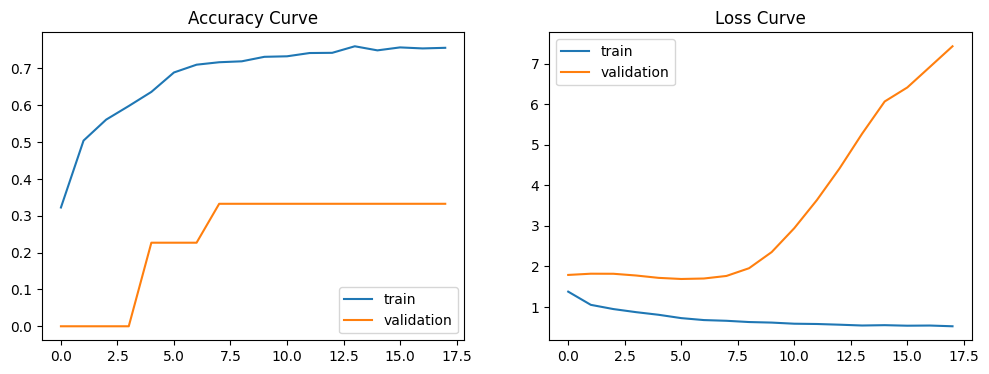

In [21]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# =========================
# PATHS
# =========================
DATASET = "/content/research_dataset"

IMG_SIZE = (224,224)

BATCH = 32

EPOCHS = 30


# =========================
# LOAD DATASET
# =========================
train_ds = image_dataset_from_directory(
    DATASET,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH
)

val_ds = image_dataset_from_directory(
    DATASET,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH
)

class_names = train_ds.class_names

print("Classes:", class_names)


# =========================
# PERFORMANCE BOOST
# =========================
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)

val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)


# =========================
# DATA AUGMENTATION
# =========================
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2)
])


# =========================
# BASE MODEL
# =========================
base_model = MobileNetV3Small(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

# Fine-Tuning
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False


# =========================
# BUILD MODEL
# =========================
model = models.Sequential([

    data_augmentation,

    layers.Rescaling(1./255),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.3),

    layers.Dense(len(class_names), activation="softmax")
])


# =========================
# COMPILE
# =========================
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# =========================
# EARLY STOPPING
# =========================
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=True
)


# =========================
y_train = np.concatenate(
    [y.numpy() for x, y in train_ds],
    axis=0
)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

# TRAIN
# =========================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop],
    class_weight=class_weights
)


# =========================
# SAVE MODEL
# =========================
model.save("/content/mobilenetv3_baseline.keras")

print("Baseline model saved.")


# =========================
# ACCURACY + LOSS CURVES
# =========================
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)

plt.plot(history.history["accuracy"], label="train")

plt.plot(history.history["val_accuracy"], label="validation")

plt.title("Accuracy Curve")

plt.legend()

# Loss
plt.subplot(1,2,2)

plt.plot(history.history["loss"], label="train")

plt.plot(history.history["val_loss"], label="validation")

plt.title("Loss Curve")

plt.legend()

plt.show()

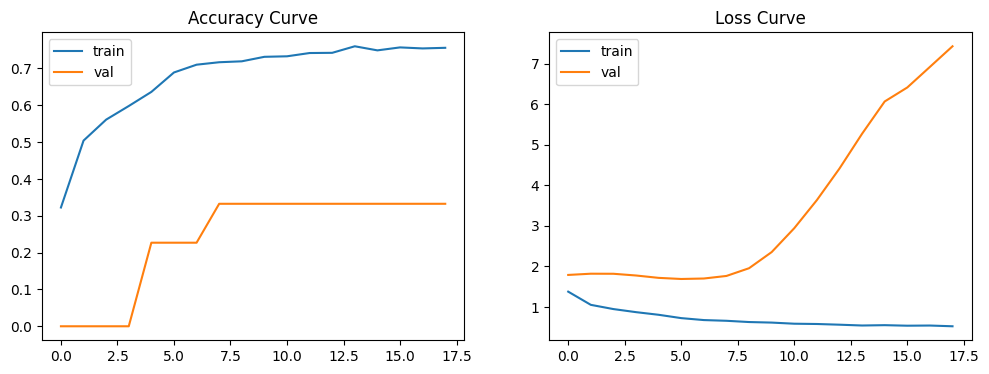

In [22]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss Curve")
plt.legend()

plt.show()

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
                   precision    recall  f1-score   support

     Early_Blight       0.23      1.00      0.37       204
          Healthy       0.00      0.00      0.00       299
      Late_Blight       0.00      0.00      0.00       396
Yellow_Curl_Virus       0.00      0.00      0.00         0

         accuracy                           0.23       899
        macro avg       0.06      0.25      0.09       899
     weighted avg       0.05      0.23      0.08       899



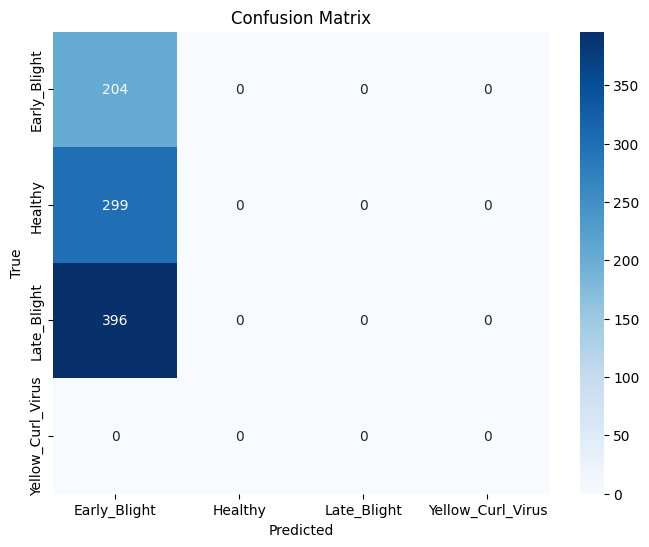

In [24]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Collect true labels
y_true = np.concatenate([y.numpy() for x, y in val_ds], axis=0)

# Predict
y_pred_probs = model.predict(val_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Force all 4 labels
labels = list(range(len(class_names)))

print(classification_report(
    y_true,
    y_pred,
    labels=labels,
    target_names=class_names,
    zero_division=0
))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [25]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# =========================
# DATASET
# =========================
DATASET = "/content/research_dataset"

IMG_SIZE = (224,224)

BATCH = 32

EPOCHS = 30


# =========================
# LOAD DATASET
# =========================
train_ds = image_dataset_from_directory(
    DATASET,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH
)

val_ds = image_dataset_from_directory(
    DATASET,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH
)

class_names = train_ds.class_names

print("Classes:", class_names)


# =========================
# PERFORMANCE BOOST
# =========================
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)

val_ds = val_ds.prefetch(AUTOTUNE)


# =========================
# DATA AUGMENTATION
# =========================
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2)
])


# =========================
# CBAM BLOCK
# =========================
def cbam_block(x, ratio=8):

    ch = int(x.shape[-1])

    # Channel Attention
    avg = layers.GlobalAveragePooling2D()(x)

    maxp = layers.GlobalMaxPooling2D()(x)

    shared_dense1 = layers.Dense(ch // ratio, activation="relu")

    shared_dense2 = layers.Dense(ch)

    avg = shared_dense2(shared_dense1(avg))

    maxp = shared_dense2(shared_dense1(maxp))

    ca = layers.Add()([avg, maxp])

    ca = layers.Activation("sigmoid")(ca)

    ca = layers.Reshape((1,1,ch))(ca)

    x = layers.Multiply()([x, ca])


    # Spatial Attention
    avg_pool = layers.Lambda(
        lambda z: tf.reduce_mean(z, axis=-1, keepdims=True)
    )(x)

    max_pool = layers.Lambda(
        lambda z: tf.reduce_max(z, axis=-1, keepdims=True)
    )(x)

    concat = layers.Concatenate(axis=-1)(
        [avg_pool, max_pool]
    )

    sa = layers.Conv2D(
        1,
        kernel_size=7,
        padding="same",
        activation="sigmoid"
    )(concat)

    x = layers.Multiply()([x, sa])

    return x


# =========================
# BACKBONE
# =========================
base = MobileNetV3Small(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

# Fine-Tuning
base.trainable = True

for layer in base.layers[:-30]:
    layer.trainable = False


# =========================
# BUILD MODEL
# =========================
inputs = layers.Input(shape=(224,224,3))

x = data_augmentation(inputs)

x = layers.Rescaling(1./255)(x)

x = base(x, training=False)

x = cbam_block(x)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation="relu")(x)

x = layers.Dropout(0.4)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

heca_model = Model(inputs, outputs)


# =========================
# COMPILE
# =========================
heca_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# =========================
# EARLY STOPPING
# =========================
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=True
)


# =========================
y_train = np.concatenate(
    [y.numpy() for x, y in train_ds],
    axis=0
)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)
# TRAIN
# =========================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop],
    class_weight=class_weights
)


# =========================
# SAVE MODEL
# =========================
heca_model.save("/content/heca_mobilenet.keras")

print("HECA model saved.")

Found 4499 files belonging to 4 classes.
Using 3600 files for training.
Found 4499 files belonging to 4 classes.
Using 899 files for validation.
Classes: ['Early_Blight', 'Healthy', 'Late_Blight', 'Yellow_Curl_Virus']
{0: np.float64(1.5075376884422111), 1: np.float64(0.9287925696594427), 2: np.float64(0.7936507936507936)}
Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.7025 - loss: 0.6960 - val_accuracy: 0.2269 - val_loss: 1.6955
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.7164 - loss: 0.6652 - val_accuracy: 0.3326 - val_loss: 1.7644
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.7197 - loss: 0.6384 - val_accuracy: 0.3326 - val_loss: 1.9828
Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.7450 - loss: 0.6150 - val_accuracy: 0.3326 - val_loss: 2.3998
Epoch 5/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - accuracy: 0.7447 - loss: 0.6050 - val_accuracy: 0.3326 - val_loss: 2.9966
Epoch 6/30
113/113 ━━━━━━━━━━━━

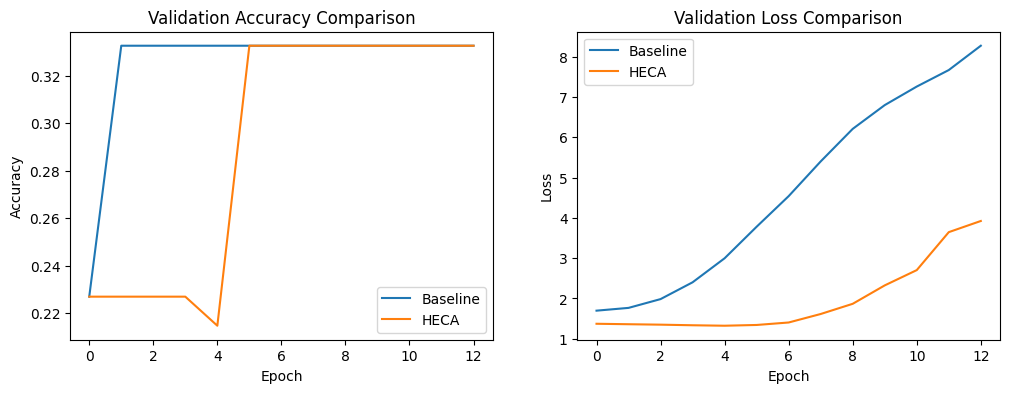

In [26]:
import matplotlib.pyplot as plt

# Find minimum common epochs
min_epochs = min(
    len(history.history["val_accuracy"]),
    len(history2.history["val_accuracy"])
)

plt.figure(figsize=(12,4))

# =========================
# ACCURACY
# =========================
plt.subplot(1,2,1)

plt.plot(
    history.history["val_accuracy"][:min_epochs],
    label="Baseline"
)

plt.plot(
    history2.history["val_accuracy"][:min_epochs],
    label="HECA"
)

plt.title("Validation Accuracy Comparison")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()


# =========================
# LOSS
# =========================
plt.subplot(1,2,2)

plt.plot(
    history.history["val_loss"][:min_epochs],
    label="Baseline"
)

plt.plot(
    history2.history["val_loss"][:min_epochs],
    label="HECA"
)

plt.title("Validation Loss Comparison")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step
                   precision    recall  f1-score   support

     Early_Blight       0.00      0.00      0.00       204
          Healthy       0.30      0.01      0.02       299
      Late_Blight       0.00      0.00      0.00       396
Yellow_Curl_Virus       0.00      0.00      0.00         0

         accuracy                           0.00       899
        macro avg       0.07      0.00      0.00       899
     weighted avg       0.10      0.00      0.01       899



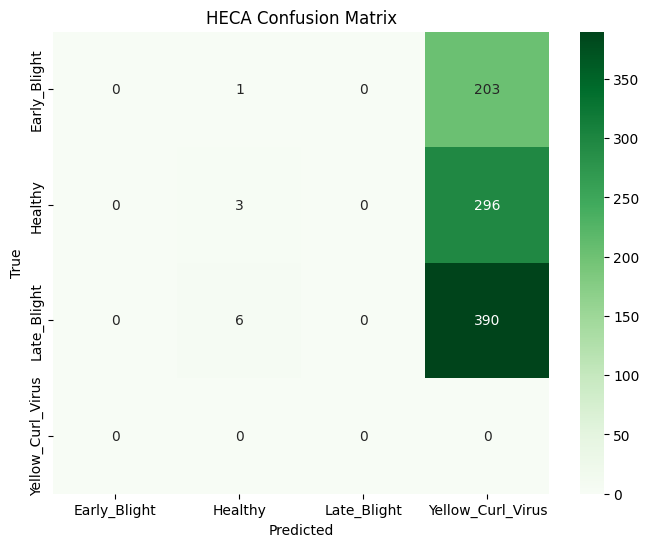

In [27]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

y_true = np.concatenate([y.numpy() for x, y in val_ds], axis=0)

y_pred_probs = heca_model.predict(val_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

labels = list(range(len(class_names)))

print(classification_report(
    y_true,
    y_pred,
    labels=labels,
    target_names=class_names,
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("HECA Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Additional Attention Model Experiments

In [15]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV3Small
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# =========================
# DATA AUGMENTATION
# =========================
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2)
])

# =========================
# SE BLOCK
# =========================
def se_block(x, ratio=8):

    ch = int(x.shape[-1])

    se = layers.GlobalAveragePooling2D()(x)

    se = layers.Dense(ch // ratio, activation="relu")(se)

    se = layers.Dense(ch, activation="sigmoid")(se)

    se = layers.Reshape((1,1,ch))(se)

    return layers.Multiply()([x, se])


# =========================
# BACKBONE
# =========================
base_se = MobileNetV3Small(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

# Fine-Tuning
base_se.trainable = True

for layer in base_se.layers[:-30]:
    layer.trainable = False


# =========================
# BUILD MODEL
# =========================
inputs = layers.Input(shape=(224,224,3))

x = data_augmentation(inputs)

x = layers.Rescaling(1./255)(x)

x = base_se(x, training=False)

x = se_block(x)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation="relu")(x)

x = layers.Dropout(0.4)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

se_model = Model(inputs, outputs)


# =========================
# COMPILE
# =========================
se_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# =========================
# EARLY STOPPING
# =========================
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=True
)


# =========================
y_train = np.concatenate(
    [y.numpy() for x, y in train_ds],
    axis=0
)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)
# TRAIN
# =========================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop],
    class_weight=class_weights
)

print("SE Model done.")

Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 18s 77ms/step - accuracy: 0.5975 - loss: 0.8530 - val_accuracy: 0.3326 - val_loss: 1.3876
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.7472 - loss: 0.5426 - val_accuracy: 0.3326 - val_loss: 1.3713
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accuracy: 0.7761 - loss: 0.4575 - val_accuracy: 0.3326 - val_loss: 1.3507
Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - accuracy: 0.7967 - loss: 0.4344 - val_accuracy: 0.3326 - val_loss: 1.3285
Epoch 5/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.7997 - loss: 0.4079 - val_accuracy: 0.3326 - val_loss: 1.3139
Epoch 6/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.7958 - loss: 0.4241 - val_accuracy: 0.3326 - val_loss: 1.2991
Epoch 7/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.8150 - loss: 0.3957 - val_accuracy: 0.3326 - val_loss: 1.3189
Epoch 8/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - accuracy: 0.8111 - loss: 0.3898 - val_

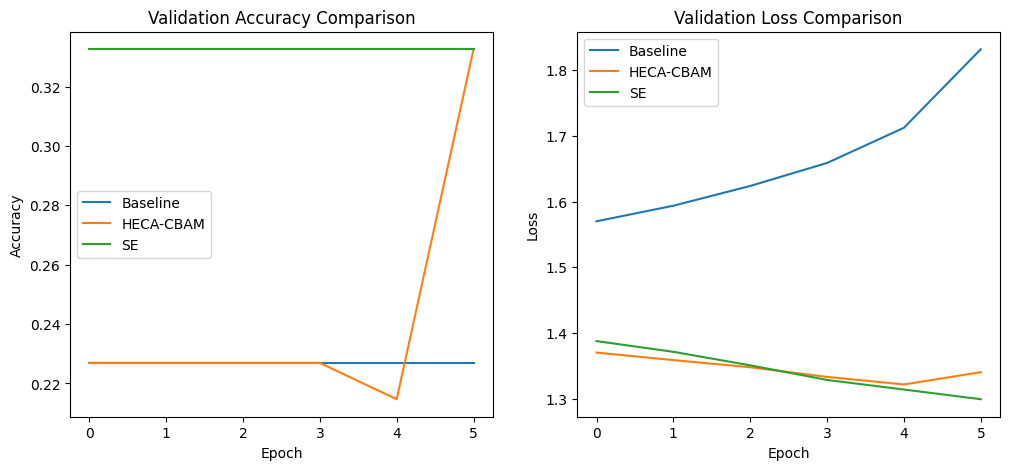

In [16]:
import matplotlib.pyplot as plt

# Common epoch length
min_epochs = min(
    len(history.history["val_accuracy"]),
    len(history2.history["val_accuracy"]),
    len(history3.history["val_accuracy"])
)

plt.figure(figsize=(12,5))

# =========================
# ACCURACY
# =========================
plt.subplot(1,2,1)

plt.plot(
    range(min_epochs),
    history.history["val_accuracy"][:min_epochs],
    label="Baseline"
)

plt.plot(
    range(min_epochs),
    history2.history["val_accuracy"][:min_epochs],
    label="HECA-CBAM"
)

plt.plot(
    range(min_epochs),
    history3.history["val_accuracy"][:min_epochs],
    label="SE"
)

plt.title("Validation Accuracy Comparison")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()


# =========================
# LOSS
# =========================
plt.subplot(1,2,2)

plt.plot(
    range(min_epochs),
    history.history["val_loss"][:min_epochs],
    label="Baseline"
)

plt.plot(
    range(min_epochs),
    history2.history["val_loss"][:min_epochs],
    label="HECA-CBAM"
)

plt.plot(
    range(min_epochs),
    history3.history["val_loss"][:min_epochs],
    label="SE"
)

plt.title("Validation Loss Comparison")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


/tmp/ipykernel_14568/759292498.py:28: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)


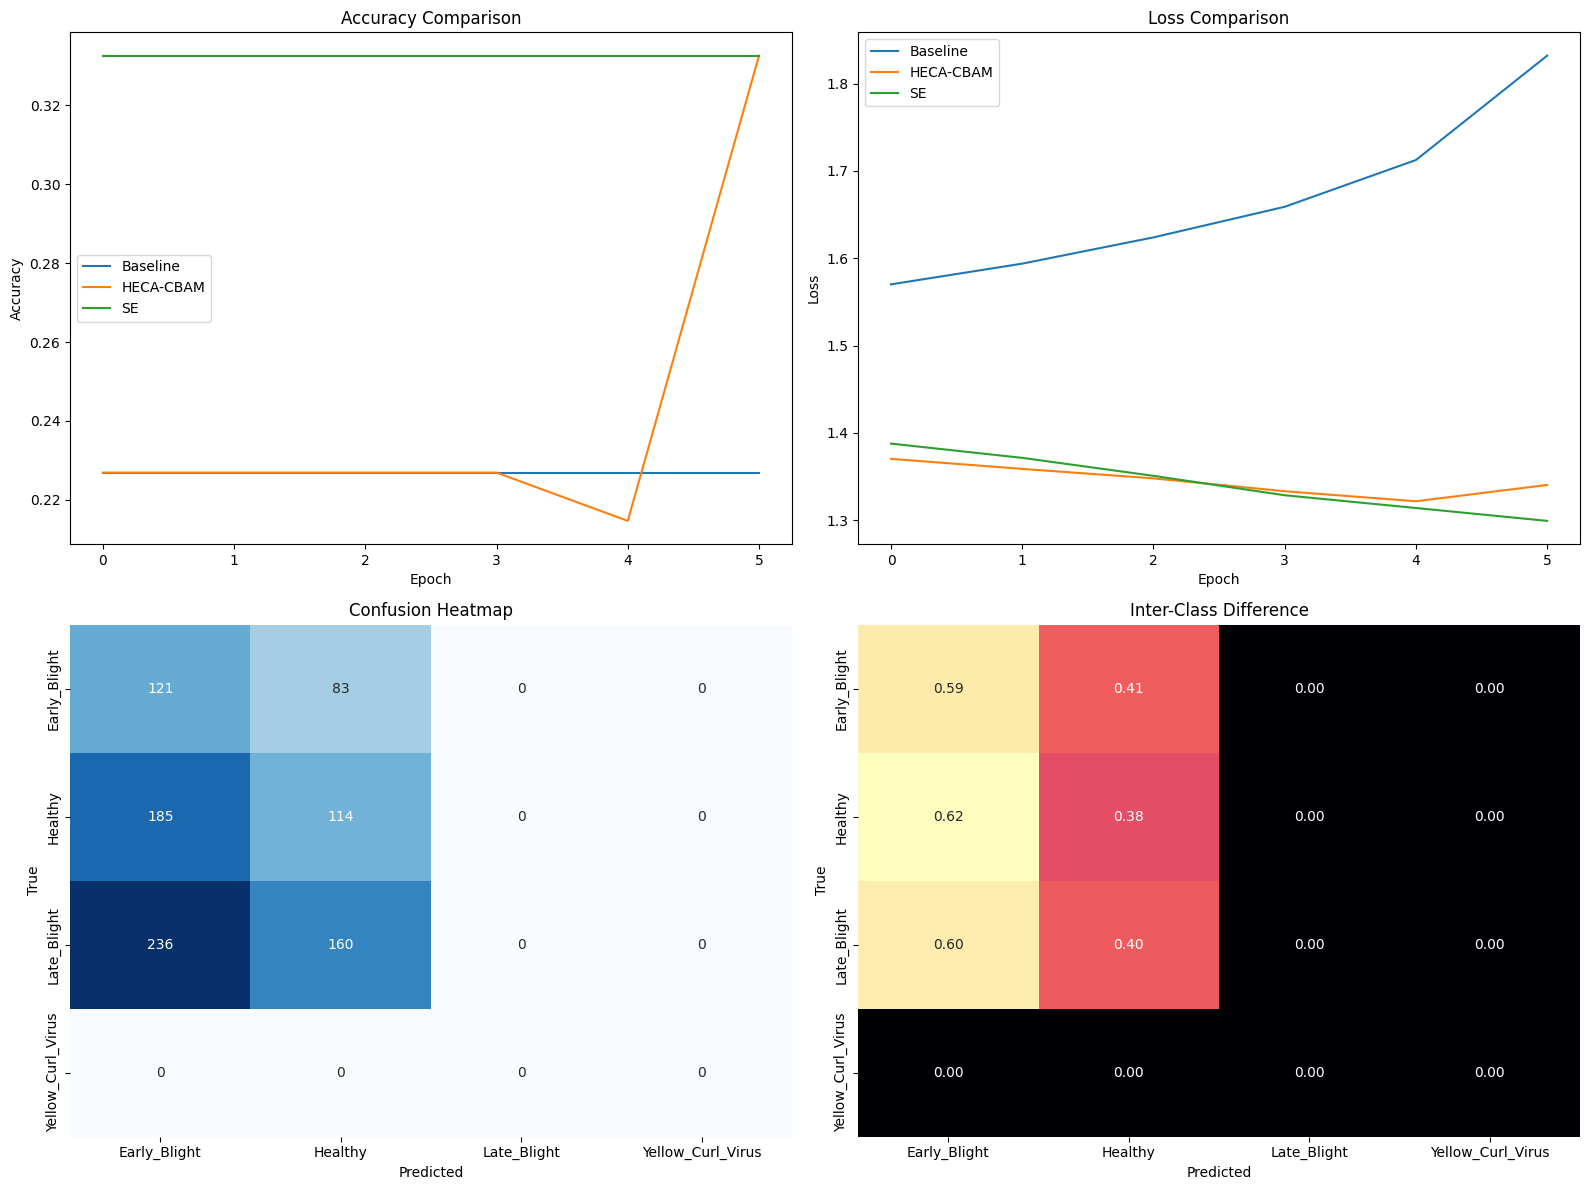

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# =========================
# PREDICTIONS
# =========================
y_true = np.concatenate([y.numpy() for x, y in val_ds], axis=0)

y_pred = np.argmax(
    heca_model.predict(val_ds),
    axis=1
)

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0,1,2,3]
)

# =========================
# NORMALIZED MATRIX
# =========================
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

cm_norm = np.nan_to_num(cm_norm)

# =========================
# COMMON EPOCH LENGTH
# =========================
min_epochs = min(
    len(history.history["val_accuracy"]),
    len(history2.history["val_accuracy"]),
    len(history3.history["val_accuracy"])
)

# =========================
# FIGURE
# =========================
plt.figure(figsize=(16,12))

# ==================================================
# 1 ACCURACY COMPARISON
# ==================================================
plt.subplot(2,2,1)

plt.plot(
    range(min_epochs),
    history.history["val_accuracy"][:min_epochs],
    label="Baseline"
)

plt.plot(
    range(min_epochs),
    history2.history["val_accuracy"][:min_epochs],
    label="HECA-CBAM"
)

plt.plot(
    range(min_epochs),
    history3.history["val_accuracy"][:min_epochs],
    label="SE"
)

plt.title("Accuracy Comparison")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

# ==================================================
# 2 LOSS COMPARISON
# ==================================================
plt.subplot(2,2,2)

plt.plot(
    range(min_epochs),
    history.history["val_loss"][:min_epochs],
    label="Baseline"
)

plt.plot(
    range(min_epochs),
    history2.history["val_loss"][:min_epochs],
    label="HECA-CBAM"
)

plt.plot(
    range(min_epochs),
    history3.history["val_loss"][:min_epochs],
    label="SE"
)

plt.title("Loss Comparison")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

# ==================================================
# 3 CONFUSION HEATMAP
# ==================================================
plt.subplot(2,2,3)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=False
)

plt.title("Confusion Heatmap")

plt.xlabel("Predicted")

plt.ylabel("True")

# ==================================================
# 4 INTER-CLASS DIFFERENCE
# ==================================================
plt.subplot(2,2,4)

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="magma",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=False
)

plt.title("Inter-Class Difference")

plt.xlabel("Predicted")

plt.ylabel("True")

# =========================
# FINAL LAYOUT
# =========================
plt.tight_layout()

plt.show()